# TotalSegmentator MRI → NPZ Conversion and Visualization

This notebook converts the **TotalSegmentator MRI** dataset (arXiv 2405.19492) into the
unified `.npz` format used by the Prompt-UNet pipeline.

**Dataset structure expected:**
```
TotalSeg_mri/
  meta.csv
  s0001/
    mri.nii.gz
    segmentations/
      adrenal_gland_left.nii.gz
      aorta.nii.gz
      ...  (56 structures)
  s0002/
    ...
```

**Important parameters:**
- `splits` — restrict to `'test'` to replicate the paper's internal test split (55 subjects)
- `crop=True` — crop to anatomy using MRI signal threshold before resampling
- Output modality tag: `'MRI'`

## 0. Setup

In [2]:
import sys
import os
from pathlib import Path
import numpy as np

project_root = Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.test_data.totalseg_to_npz import process_totalseg_dataset
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Convert the Dataset

Edit the variables below to match your local setup.

| Option | Description |
|---|---|
| `DATA_DIR` | Path to the root `TotalSeg_mri/` directory |
| `OUTPUT_NAME` | Name for the output `.npz` file (without extension) |
| `SPLITS` | `None` for all subjects, or e.g. `['test']` for the paper's test split |
| `CROP` | Whether to crop volumes to their anatomy bounding box |
| `MARGIN` | Voxel margin added around the bounding box when cropping |

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR    = "TotalSeg_mri"   # relative to this notebook, or use an absolute path
OUTPUT_NAME = "TotalSeg_mri"  # output will be saved as TotalSeg_mri.npz
SPLITS      = None            # None → all subjects; ['test'] → test split only
CROP        = True
MARGIN      = 15
# ───────────────────────────────────────────────────────────────────────────

if os.path.isdir(DATA_DIR):
    process_totalseg_dataset(
        data_dir=DATA_DIR,
        output_filename=OUTPUT_NAME,
        crop=CROP,
        margin=MARGIN,
        splits=SPLITS,
    )
else:
    print(f"Data directory '{DATA_DIR}' not found.\n"
          "Please set DATA_DIR to the correct path.")

Processing 149 subject(s) from 'TotalSeg_mri' ...

[1/149] Processing s0001 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('4.40', '0.74', '0.74') mm → 1.0 mm isotropic ...
  -> Resampled shape: (334, 377, 380)

[2/149] Processing s0003 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('5.00', '1.02', '1.02') mm → 1.0 mm isotropic ...
  -> Resampled shape: (155, 260, 258)

[3/149] Processing s0005 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('1.88', '10.00', '1.88') mm → 1.0 mm isotropic ...
  -> Resampled shape: (480, 170, 480)

[4/149] Processing s0007 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('8.00', '0.86', '0.86') mm → 1.0 mm isotropic ...
  -> Resampled shape: (224, 358, 407)

[5/149] Processing s0009 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('8.00', '1.41', '1.41') mm → 1.0 mm isotropic ...
  -> Resampled shape: (208, 319, 357)

[6/149] Processing s0011 ...
  Cr

## 2. Load the Generated .npz and Inspect

We use `DataLoader_npz` to load the compressed archive and inspect its contents.

In [4]:
npz_path = f"data/test_data/{OUTPUT_NAME}.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids

print(f"Loaded {len(all_ids)} subjects from {npz_path}")
print(f"Subject IDs (first 10): {all_ids[:10]}")

# Pick a sample subject
sample_id = all_ids[0]
img  = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']
modality = dg.dataloader.dataset[sample_id]['modality']

print(f"\nSample: {sample_id}")
print(f"  Modality     : {modality}")
print(f"  Image shape  : {img.shape}")
print(f"  Image dtype  : {img.dtype}")
print(f"  Image range  : [{img.min():.1f}, {img.max():.1f}]")
print(f"  Mask shape   : {mask.shape if isinstance(mask, np.ndarray) else mask[0].shape}")
print(f"  Mask labels  : {np.unique(mask) if isinstance(mask, np.ndarray) else np.unique(mask[0])}")


Loading NPZ dataset(s)…
Loaded 149 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\TotalSeg_mri.npz

Final dataset size: 149 patients.

Loaded 149 subjects from data/test_data/TotalSeg_mri.npz
Subject IDs (first 10): ['TotalSeg_mri_s0199', 'TotalSeg_mri_s0033', 'TotalSeg_mri_s0017', 'TotalSeg_mri_s0263', 'TotalSeg_mri_s0093', 'TotalSeg_mri_s0215', 'TotalSeg_mri_s0097', 'TotalSeg_mri_s0005', 'TotalSeg_mri_s0127', 'TotalSeg_mri_s0125']

Sample: TotalSeg_mri_s0199
  Modality     : MRI
  Image shape  : (216, 312, 400)
  Image dtype  : float32
  Image range  : [0.0, 1129.1]
  Mask shape   : (216, 312, 400)
  Mask labels  : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26]


## 4. Static Multi-Slice Grid

Shows a persistent overview of the volume (saved in the notebook output).

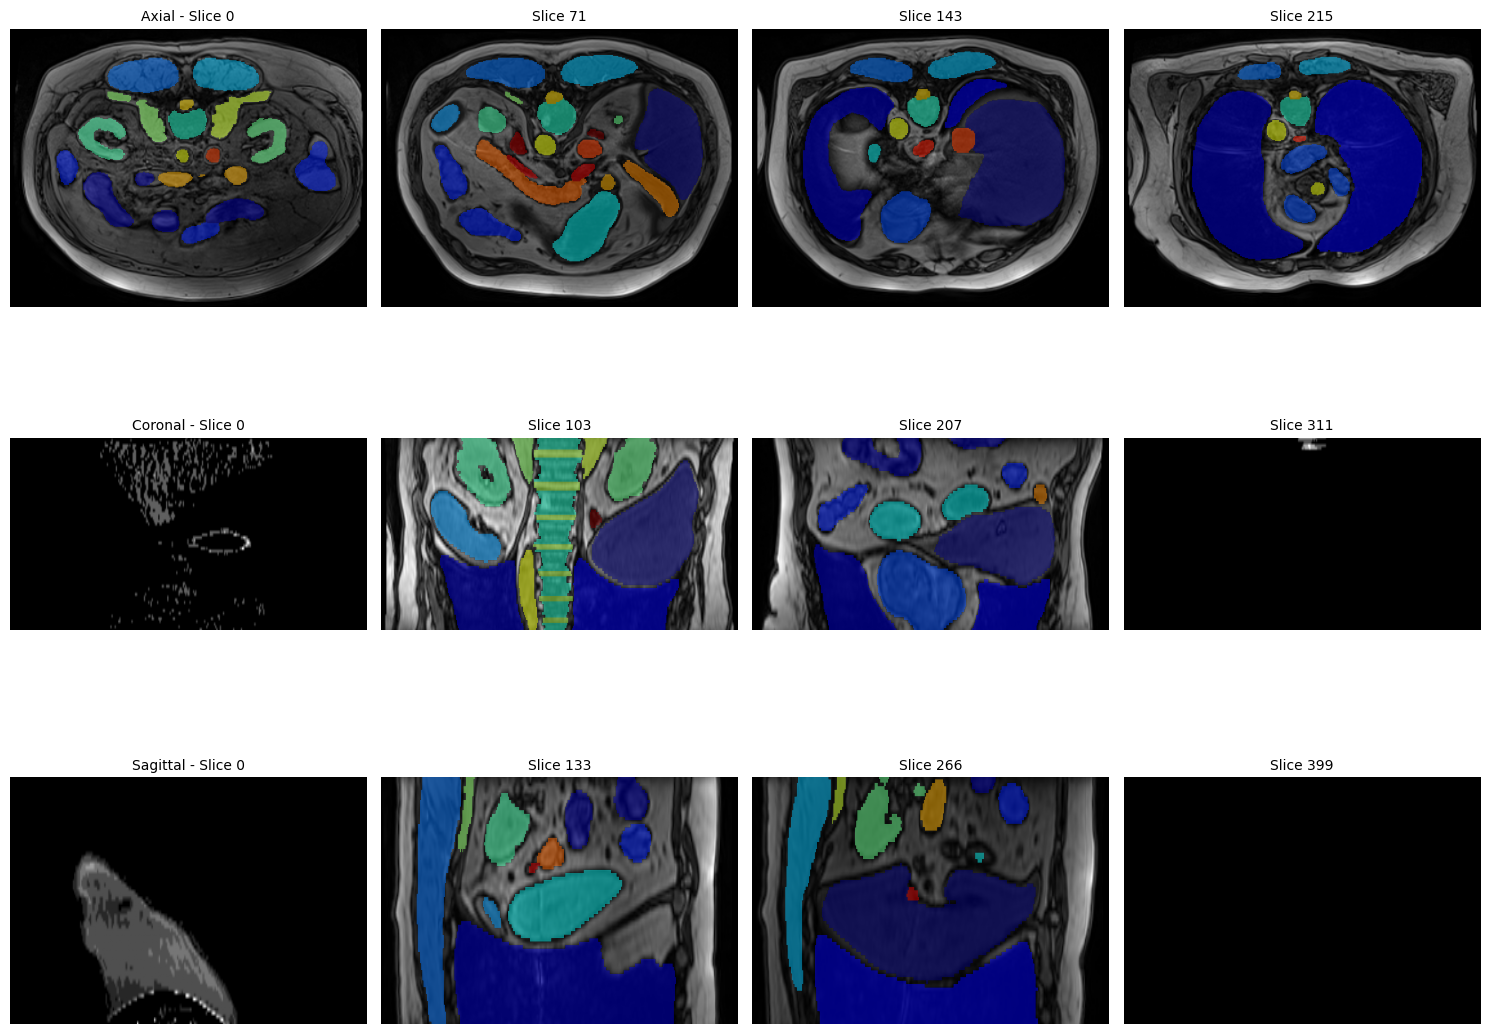

In [10]:
plot_vol_slices(img, mask_array, num_slices=4)

## 5. Dataset Statistics

Quick sanity-check across all loaded subjects.

In [11]:
import pandas as pd

rows = []
for sid in all_ids:
    sample = dg.dataloader.dataset[sid]
    im = sample['image']
    ms = sample['segmentations']
    ms_arr = ms if isinstance(ms, np.ndarray) else ms[0]
    rows.append({
        'subject':    sid,
        'modality':   sample['modality'],
        'shape':      str(im.shape),
        'n_labels':   int(ms_arr.max()),
        'pct_labeled': float(np.mean(ms_arr > 0)) * 100,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nMean labelled voxels: {df['pct_labeled'].mean():.1f} %")

           subject modality            shape  n_labels  pct_labeled
TotalSeg_mri_s0199      MRI  (216, 312, 400)        26    24.804914
TotalSeg_mri_s0033      MRI  (454, 165, 480)        48    24.545132
TotalSeg_mri_s0017      MRI  (232, 300, 360)        42    23.405607
TotalSeg_mri_s0263      MRI  (448, 216, 362)        56    26.161741
TotalSeg_mri_s0093      MRI  (158, 242, 360)        44    13.048269
TotalSeg_mri_s0215      MRI  (448, 122, 366)        44    35.179210
TotalSeg_mri_s0097      MRI    (96, 86, 150)        55     4.784561
TotalSeg_mri_s0005      MRI  (480, 170, 480)        48    19.306467
TotalSeg_mri_s0127      MRI  (144, 155, 360)        44    28.295811
TotalSeg_mri_s0125      MRI  (119, 200, 200)        23    24.062143
TotalSeg_mri_s0173      MRI  (399, 192, 400)        48    21.890981
TotalSeg_mri_s0237      MRI  (469, 216, 382)        56    19.901151
TotalSeg_mri_s0153      MRI  (448, 123, 366)        43    26.882947
TotalSeg_mri_s0137      MRI   (300, 274, 79)    

## 6. Meta-CSV Overview

Inspect the per-subject metadata shipped with the dataset.

In [12]:
meta_path = os.path.join(DATA_DIR, "meta.csv")
if os.path.exists(meta_path):
    meta_df = pd.read_csv(meta_path, sep=";")
    print(f"Meta CSV shape: {meta_df.shape}")
    print("\nSplit distribution:")
    print(meta_df['split'].value_counts())
    print("\nMagnetic field strength distribution:")
    print(meta_df['magnetic_field_strength'].value_counts())
    display(meta_df.head(10))
else:
    print(f"meta.csv not found at {meta_path}")

Meta CSV shape: (298, 14)

Split distribution:
split
train    268
test      30
Name: count, dtype: int64

Magnetic field strength distribution:
magnetic_field_strength
1.50    152
3.00    138
0.55      7
1.00      1
Name: count, dtype: int64


,image_id,age,gender,institute,study_type,manufacturer,scanner_model,slice_thickness,scanning_sequence,repetition_time,echo_time,magnetic_field_strength,source,split
0,s0001,NaN,NaN,C,unkown,ge,SIGNA Explorer,4.4,GR,0.01,0.00,1.5,idc,train
1,s0002,NaN,NaN,C,unkown,ge,Signa HDxt,6.0,SE,3.55,0.15,1.5,idc,test
2,s0003,NaN,NaN,C,unkown,ge,Optima MR450w,5.0,EP\SE,8.00,0.10,1.5,idc,train
3,s0004,NaN,NaN,C,unkown,ge,Signa HDxt,3.0,SE,2.43,0.11,1.5,idc,train
4,s0005,NaN,NaN,C,unkown,ge,GENESIS_SIGNA,8.0,SE,1.53,0.16,1.5,idc,train
5,s0006,NaN,NaN,C,unkown,ge,GENESIS_SIGNA,8.0,SE,2.12,0.09,1.5,idc,train
6,s0007,NaN,NaN,C,unkown,ge,GENESIS_SIGNA,8.0,GR,0.00,0.00,1.5,idc,train
7,s0008,NaN,NaN,C,unkown,ge,SIGNA EXCITE,7.0,SE,0.65,0.01,1.5,idc,train
8,s0009,NaN,NaN,C,unkown,ge,GENESIS_SIGNA,7.0,GR,0.21,0.00,1.5,idc,train
9,s0010,NaN,NaN,C,unkown,ge,SIGNA EXCITE,3.0,GR,0.00,0.00,1.5,idc,train
